# Lead Scoring Notebook

This notebook is organized as a full workflow:
1. EDA
2. Data preparation
3. Model training and comparison
4. Performance curves
5. Threshold selection
6. Confusion matrix and classification report
7. Lead score table

In [2]:

import os
from typing import List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

IDENTIFIER_COLUMNS = ["Prospect ID", "Lead Number"]
PLACEHOLDER_VALUES = ["Select", "", " "]
HIGH_CARDINALITY_THRESHOLD = 100
DATA_PATH = "Lead Scoring.csv"
OUT_DIR = "models"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# helper functions
def normalize_placeholders(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for val in PLACEHOLDER_VALUES:
        df.replace(val, np.nan, inplace=True)
    return df


def coerce_numeric_like_columns(df: pd.DataFrame, threshold: float = 0.7) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            coerced = pd.to_numeric(df[col], errors="coerce")
            if coerced.notna().mean() >= threshold:
                df[col] = coerced
    return df


def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = normalize_placeholders(df)
    df = coerce_numeric_like_columns(df)
    return df


def split_features_target(df: pd.DataFrame, target_col: str = "Converted") -> Tuple[pd.DataFrame, pd.Series]:
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe")
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


def _drop_identifier_and_high_cardinality(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    to_drop: List[str] = [c for c in IDENTIFIER_COLUMNS if c in X.columns]
    for c in X.select_dtypes(include=[object, "category"]).columns:
        try:
            nunique = X[c].nunique(dropna=True)
        except Exception:
            nunique = 0
        if nunique > HIGH_CARDINALITY_THRESHOLD:
            to_drop.append(c)
    if to_drop:
        to_drop = list(dict.fromkeys(to_drop))
        print(f"Dropping columns due to identifiers/high-cardinality: {to_drop}")
        X = X.drop(columns=[c for c in to_drop if c in X.columns])
    return X


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    X_reduced = _drop_identifier_and_high_cardinality(X)
    numeric_cols = X_reduced.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_reduced.select_dtypes(include=[object, "category"]).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    try:
        categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", categorical_encoder),
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def fit_and_save_preprocessor(X: pd.DataFrame, out_path: str) -> None:
    preprocessor = build_preprocessor(X)
    preprocessor.fit(X)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    joblib.dump(preprocessor, out_path)


def load_preprocessor(path: str) -> ColumnTransformer:
    return joblib.load(path)


def transform_with_preprocessor(preprocessor: ColumnTransformer, X: pd.DataFrame):
    return preprocessor.transform(X)

In [4]:
#  EDA
raw_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", raw_df.shape)


Dataset shape: (9240, 37)


In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [6]:
print("\nColumns: ")
print(raw_df.columns.tolist())
print("\nFirst 5 rows:")
display(raw_df.head())



Columns: 
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

First 5 rows:


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [7]:

print("\nMissing values:")
print(raw_df.isnull().sum())




Missing values:
Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper A

In [8]:

print("\nTarget distribution:")
print(raw_df["Converted"].value_counts(normalize=True))



Target distribution:
Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64


In [9]:

print("\nNumeric columns summary:")
display(raw_df.describe(include=[np.number]))



Numeric columns summary:


,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [10]:

print("\nCategorical columns summary:")
cat_cols = raw_df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    print(f"\n{col}:")
    print(raw_df[col].value_counts().head(10))


Categorical columns summary:

Prospect ID:
Prospect ID
571b5c8e-a5b2-4d57-8574-f2ffb06fdeff    1
7927b2df-8bba-4d29-b9a2-b6e0beafe620    1
2a272436-5132-4136-86fa-dcc88c88f482    1
8cc8c611-a219-4f35-ad23-fdfd2656bd8a    1
0cc2df48-7cf4-4e39-9de9-19797f9b38cc    1
3256f628-e534-4826-9d63-4a8b88782852    1
2058ef08-2858-443e-a01f-a9237db2f5ce    1
9fae7df4-169d-489b-afe4-0f3d752542ed    1
c55de92b-9295-40e1-90e8-a628c349c292    1
68e53bdc-b66d-48ef-8592-973a8a65377e    1
Name: count, dtype: int64

Lead Origin:
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64

Lead Source:
Lead Source
Google              2868
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
bing                   6
google                 5
Name: coun

In [11]:
# Step 4: Prepare data and train/test split
df = load_data(DATA_PATH)
#drop id and lead number beacuse they are not useful for prediction
drop_cols = [c for c in ["Prospect ID", "Lead Number"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

X, y = split_features_target(df, target_col="Converted")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.3f}")
print(f"Test conversion rate: {y_test.mean():.3f}")

Train shape: (7392, 34)
Test shape: (1848, 34)
Train conversion rate: 0.385
Test conversion rate: 0.385


In [12]:
X_train['Asymmetrique Profile Index'].value_counts(dropna=False)

Asymmetrique Profile Index
NaN          3355
02.Medium    2265
01.High      1747
03.Low         25
Name: count, dtype: int64

In [13]:
# Train multiple models for comparison -> lr, randomforest, xgBoost
preproc_path = os.path.join(OUT_DIR, "preprocessor.joblib")
fit_and_save_preprocessor(X_train, preproc_path)

preprocessor = load_preprocessor(preproc_path)
X_train_t = transform_with_preprocessor(preprocessor, X_train)
X_test_t = transform_with_preprocessor(preprocessor, X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
    )

results = {}
for name, model in models.items():
    model.fit(X_train_t, y_train)
    y_prob_model = model.predict_proba(X_test_t)[:, 1]
    y_pred_model = (y_prob_model >= 0.5).astype(int)

    results[name] = {
        "model": model,
        "roc_auc": roc_auc_score(y_test, y_prob_model),
        "pr_auc": average_precision_score(y_test, y_prob_model),
        "precision": precision_score(y_test, y_pred_model, zero_division=0),
        "recall": recall_score(y_test, y_pred_model, zero_division=0),
        "f1": f1_score(y_test, y_pred_model, zero_division=0),
        "proba": y_prob_model,
    }


,ROC-AUC,PR-AUC,Precision@0.5,Recall@0.5,F1@0.5
XGBoost,0.975301,0.962493,0.885359,0.900281,0.892758
Logistic Regression,0.963781,0.939372,0.864065,0.901685,0.882474
Random Forest,0.954689,0.931314,0.854749,0.859551,0.857143


<Figure size 1000x500 with 0 Axes>

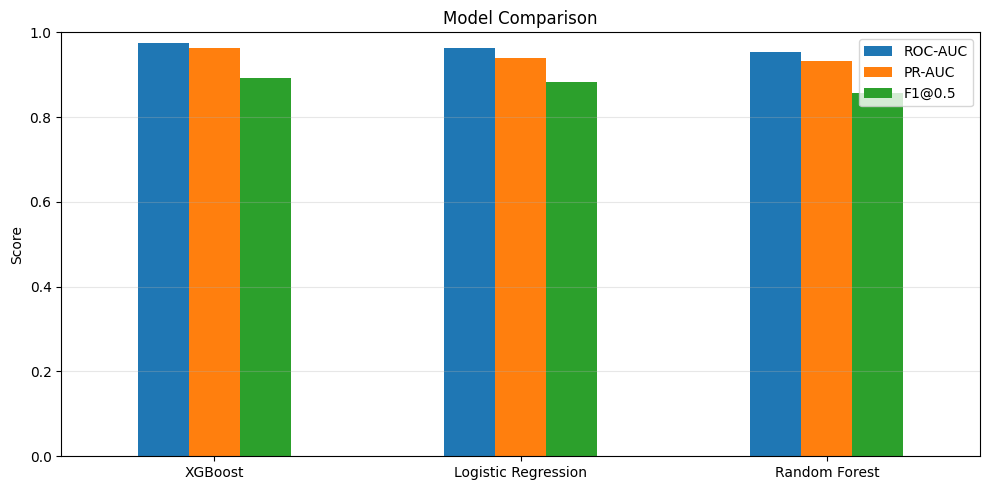

Best model by ROC-AUC: XGBoost
Model training completed.


In [14]:

comparison_df = pd.DataFrame(
    {
        name: {
            "ROC-AUC": metrics["roc_auc"],
            "PR-AUC": metrics["pr_auc"],
            "Precision@0.5": metrics["precision"],
            "Recall@0.5": metrics["recall"],
            "F1@0.5": metrics["f1"],
        }
        for name, metrics in results.items()
    }
).T.sort_values(by="ROC-AUC", ascending=False)

display(comparison_df)

plt.figure(figsize=(10, 5))
comparison_df[["ROC-AUC", "PR-AUC", "F1@0.5"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

best_model_name = comparison_df.index[0]
print(f"Best model by ROC-AUC: {best_model_name}")

# Use the best model for the rest of the notebook
best_model = results[best_model_name]["model"]
y_prob = results[best_model_name]["proba"]
print("Model training completed.")

In [15]:
import os
import joblib

model_path = os.path.join("models", "model.joblib")
joblib.dump(best_model, model_path)
print(f"Saved model to {model_path}")

Saved model to models\model.joblib


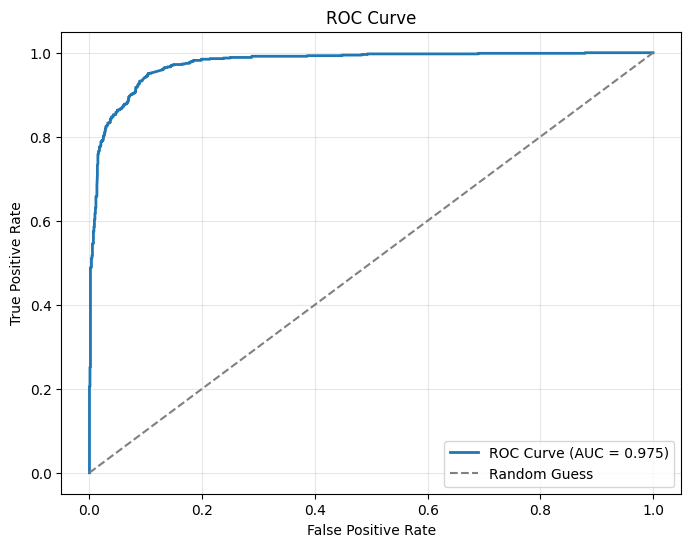

In [16]:
# Performance visuals and optimal cutoff
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


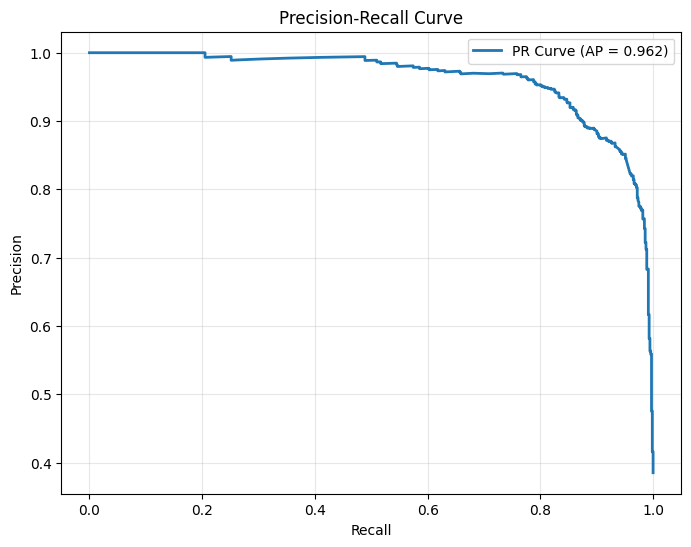

In [17]:

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'PR Curve (AP = {pr_auc:.3f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


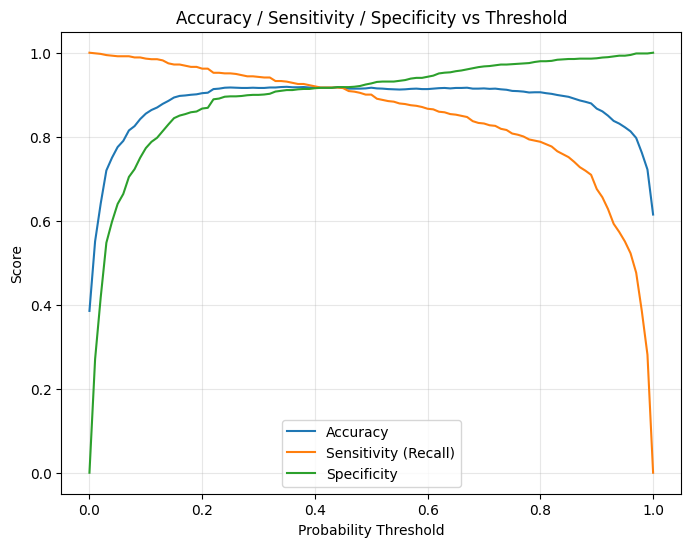

In [18]:

thresholds = np.linspace(0, 1, 101)
accuracy_scores = []
sensitivity_scores = []
specificity_scores = []

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    accuracy_scores.append((tp + tn) / len(y_test))
    sensitivity_scores.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, accuracy_scores, label='Accuracy')
plt.plot(thresholds, sensitivity_scores, label='Sensitivity (Recall)')
plt.plot(thresholds, specificity_scores, label='Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Accuracy / Sensitivity / Specificity vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() 


In [19]:

best_idx = np.argmin(np.abs(np.array(sensitivity_scores) - np.array(specificity_scores)))
optimal_threshold = thresholds[best_idx]
print(f'Estimated optimal cutoff: {optimal_threshold:.3f}')

Estimated optimal cutoff: 0.410


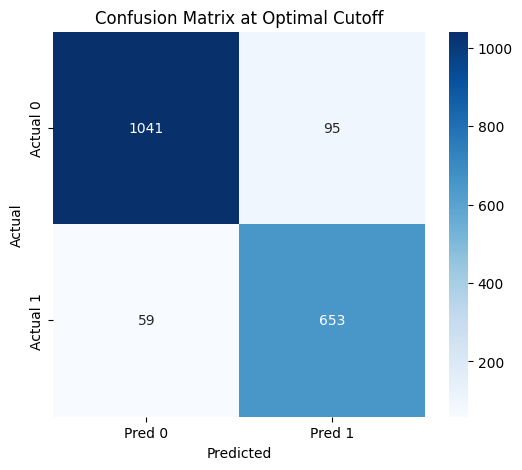

               precision    recall  f1-score   support

Not Converted       0.95      0.92      0.93      1136
    Converted       0.87      0.92      0.89       712

     accuracy                           0.92      1848
    macro avg       0.91      0.92      0.91      1848
 weighted avg       0.92      0.92      0.92      1848

Precision: 0.8730
Recall: 0.9171
F1 Score: 0.8945


In [20]:
#  Final evaluation at optimal cutoff
y_pred_opt = (y_prob >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix at Optimal Cutoff')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred_opt, target_names=['Not Converted', 'Converted']))
print(f'Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_opt, zero_division=0):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_opt, zero_division=0):.4f}')

In [21]:
# Step 8: lead score table
lead_ids = X_test['Prospect ID'] if 'Prospect ID' in X_test.columns else X_test.index
score_df = pd.DataFrame({
    'Lead ID': lead_ids,
    'Predicted Probability': y_prob,
})
score_df['Lead Score'] = (score_df['Predicted Probability'] * 100).round().astype(int)
score_df['Lead Tier'] = pd.cut(
    score_df['Lead Score'],
    bins=[-1, 30, 60, 100],
    labels=['Cold', 'Warm', 'Hot']
)
score_df['Suggested Action'] = np.select(
    [score_df['Lead Score'] >= 70, score_df['Lead Score'] >= 40],
    ['Immediate Call', 'Nurture Email'],
    default='No Action'
)

final_table = score_df[['Lead ID', 'Predicted Probability', 'Lead Score', 'Lead Tier', 'Suggested Action']].head(10)
display(final_table)

score_df.to_csv(os.path.join(OUT_DIR, 'lead_scores_table.csv'), index=False)

,Lead ID,Predicted Probability,Lead Score,Lead Tier,Suggested Action
0,683,0.740297,74,Hot,Immediate Call
1,1931,0.895523,90,Hot,Immediate Call
2,6950,0.059301,6,Cold,No Action
3,2996,0.011091,1,Cold,No Action
4,3902,0.015196,2,Cold,No Action
5,6828,0.046805,5,Cold,No Action
6,4906,0.706836,71,Hot,Immediate Call
7,5796,0.028814,3,Cold,No Action
8,6388,0.212545,21,Cold,No Action
9,3636,0.030441,3,Cold,No Action
